# Topic Modeling Movie Plots with NMF and SVD

## When math makes life simpler

Imagine scrolling through a streaming service (Netflix or Crunchyroll) with thousands of titles. And you just finished a mind-bending sci-fi thriller, but the recommendation engine keeps suggesting romantic comedies. It would be very frustrating.... But what if we could teach machines to truly understand what makes a movie a movie, not just by reading genre tags, but by digesting the actual story summaries?


This is where topic modeling enters the scene, and specifically, Non-negative Matrix Factorization (NMF) and Singular Value decompositions (SVD) , two of the most powerful linear algebra techniques that can read through hundreds of movie plots and discover the hidden themes that connect them. No human labeling required. Just pure mathematics meeting storytelling.

We'll walk through applying NMF to a real-world dataset—the CMU Movie Summary Corpus containing 42,306 movie plots scraped from Wikipedia and watch as matrix decomposition uncovers the genre encoded in every story.

## Why movie plot topic modelling matters

### 1. **The Cold Start Problem in Recommendation Systems**

Every streaming platform faces this daily: new content arrives with minimal metadata. Traditional collaborative filtering (Amazon's "users who liked X also liked Y") fails catastrophically, as we can't recommend based on user behavior that doesn't exist yet.

*Solution*: Content-based filtering using plot analysis. Extract thematic features directly from the story summary, match against user preferences for similar themes, generate recommendations immediately. No waiting for hundreds of user ratings to accumulate.

*Impact*: Netflix estimates that 80% of content watched comes through recommendations. Even a 1% improvement in recommendation quality translates to millions in retained subscription revenue.


### 2. The cross-cultural defiance:

A Western algorithm might label RRR as "Action." However, NMF would decompose it into latent factors like Hyper-stylized Brotherhood, Anti-colonial Sentiment, and Musical Melodrama. This allows the system to recommend it to someone who liked Lagaan (Historical Drama) or Sholay (Western Thriller), even though their "Action" levels vary wildly.

**Thematic Overlap vs. Genre Labels**:

Traditional tagging might categorize Pushpa: The Rise as "Crime/Action" and Jersey as "Sports/Drama."
The NMF Advantage: It discovers a shared latent factor of the "Underdog Uprising."
A viewer who resonates with the emotional struggle of the protagonist in Jersey might be recommended Pushpa not for the violence, but for the "rise-from-nothing" thematic structure.

**Cultural Nuance (The "Sentiment" Factor)**:

In Telugu cinema, "Mother Sentiment" or "Sister Sentiment" is a powerful thematic driver that Western genres don't have a checkbox for. NMF picks this up from user behavior data. If you watch Billa (Stylized Action) and Chatrapathi (Action Drama), NMF realizes you aren't just an "Action" fan—you specifically gravitate toward the "Protector" factor.

### 3. Content Strategy and Market Intelligence:

Studios investing $200M in a film need market intelligence, are zombie apocalypse stories oversaturated? Is there demand for historical romances set in precolonial Africa? What narrative themes are trending?

*Topic modeling reveals*: By tracking topic distributions over time, content strategists identify emerging themes, declining genres, and untapped opportunities—all from analyzing plot structures rather than just box office receipts.

*Case study*: Around 2015, Hollywood data scientists noticed a surge in "found family" themes (characters forming bonds outside biological relations) across successful franchises (*Fast & Furious*, *Guardians of the Galaxy*, *Stranger Things*). This insight informed development decisions worth billions.

### 4. Accessibility Through Automated Metadata

Archive of thousands of older films, independent productions, and international cinema lack proper tagging. Running topic models on plot summaries automatically generates rich, searchable metadata.

*User benefit*: Semantic search. Users searching "films about redemption through sacrifice" find relevant movies even if those exact words never appeared in genre tags. The system understands themes, not just keywords.



### The Implementation part:

imports of different modules:

In [2]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn import decomposition
import os
import re
import matplotlib.pyplot as plt

import kagglehub
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
%matplotlib inline
np.set_printoptions(suppress=True)

## Load the data
### The Dataset: CMU Movie Summary Corpus

We're using the **CMU Movie Summary Corpus**, created by researchers at Carnegie Mellon University from Wikipedia data.

**Specifications:**
- 42,306 movie plot summaries (English language)
- *Coverage*: Silent era to 2012
- *Diversity*: Hollywood blockbusters, independent films, international cinema, documentaries
- *Metadata included*: Release year, genres, character names, actors
- *Source*: Wikipedia (crowdsourced, variable quality but generally well-structured)
- *Public availability*: Free download for research use

**Dataset characteristics:**
- Plot length: Median ~150 words, range 20-2000+ words
- Quality: Variable (Wikipedia-sourced) but representative of real-world data
- Size: Large enough for meaningful topic discovery, small enough to process on a laptop

In [4]:
path = kagglehub.dataset_download("msafi04/movies-genre-dataset-cmu-movie-summary")

In [5]:
print("Path to dataset files:", path)

Path to dataset files: C:\Users\Pulicharla Teja\.cache\kagglehub\datasets\msafi04\movies-genre-dataset-cmu-movie-summary\versions\1


In [6]:
data_file=None
list(os.walk(path))

[('C:\\Users\\Pulicharla Teja\\.cache\\kagglehub\\datasets\\msafi04\\movies-genre-dataset-cmu-movie-summary\\versions\\1',
  ['MovieSummaries'],
  []),
 ('C:\\Users\\Pulicharla Teja\\.cache\\kagglehub\\datasets\\msafi04\\movies-genre-dataset-cmu-movie-summary\\versions\\1\\MovieSummaries',
  [],
  ['character.metadata.tsv',
   'movie.metadata.tsv',
   'name.clusters.txt',
   'plot_summaries.txt',
   'README.txt',
   'tvtropes.clusters.txt'])]

In [7]:
summaries_dir=os.path.join(path,'MovieSummaries')
plot_summaries=os.path.join(summaries_dir,'plot_summaries.txt')


if os.path.exists(plot_summaries):
    movie_sum=[]
    try:
        with open(plot_summaries,'r',encoding='utf-8') as f:
            for line in f:
                match=re.match(r'(\d+)(.*)',line.strip())
                if match:
                    movie_id=int(match.group(1))
                    summary=match.group(2).strip()
                    movie_sum.append({'movide_id': movie_id,'plot_summary':summary})
                else:
                    print(f"Data is not parsable,{line.strip()}")
            df_summary=pd.DataFrame(movie_sum)
            plot_summaries=df_summary['plot_summary'].astype(str)
            print(len(plot_summaries))
            print('\n\n'.join(plot_summaries[:3]))

    except Exception as e:
        print(f"error parsing file: {e}")
        exit()
else:
    print("ERRRRRRRORRRRRR")
    exit()
                

42306
Shlykov, a hard-working taxi driver and Lyosha, a saxophonist, develop a bizarre love-hate relationship, and despite their prejudices, realize they aren't so different after all.

The nation of Panem consists of a wealthy Capitol and twelve poorer districts. As punishment for a past rebellion, each district must provide a boy and girl  between the ages of 12 and 18 selected by lottery  for the annual Hunger Games. The tributes must fight to the death in an arena; the sole survivor is rewarded with fame and wealth. In her first Reaping, 12-year-old Primrose Everdeen is chosen from District 12. Her older sister Katniss volunteers to take her place. Peeta Mellark, a baker's son who once gave Katniss bread when she was starving, is the other District 12 tribute. Katniss and Peeta are taken to the Capitol, accompanied by their frequently drunk mentor, past victor Haymitch Abernathy. He warns them about the "Career" tributes who train intensively at special academies and almost always 

#### Breakdown of the Regex r'(\d+)(.*)':

- .match(): This function checks if the pattern matches at the beginning of the string Python re.match Docs.
  
- line.strip(): Removes any leading or trailing whitespace (like \n or spaces) before searching.
  
- (\d+) (Group 1):
    - \d matches any digit (0-9).
    - '+' means "one or more." The parentheses () capture this part as the first group.

- (.*) (Group 2):

    - . matches any character except a newline.
    - '*' means "zero or more."
    - The parentheses () capture everything following the numbers as the second group.

| Input line | match.group(1) | match.group(2) |
|------------|----------------|----------------|
| "1 RRR" | "1" | " RRR" |
| "126 Magadheera" | "126" | " Magadheera" |
| "2024 Kalki 2898 AD" | "2024" | " Kalki 2898 AD" |


#### TopicFrequency - Inverse Document Frequency
[Topic Frequency-Inverse Document Frequency](http://www.tfidf.com/) (TF-IDF) is a way to normalize term counts by taking into account how often they appear in a document, how long the document is, and how commmon/rare the term is.

TF = (# occurrences of term t in document) / (# of words in documents)

IDF = log(# of documents / # documents with term t in it)

**IDF formula**:

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \log\left(\frac{N}{1 + \text{DF}(t)}\right)$$

Where:
- TF(t, d) = frequency of term $t$ in document $d$
- DF(t) = number of documents containing term $t$
- N = total documents
  
**Why we need this**: "Love" appearing 15 times in a romance plot is highly informative (high TF, moderate DF). "The" appearing 50 times is not (high TF, but DF ≈ N, so IDF ≈ 0). As such to get the high information density objects all the time.

In [10]:
vectorizer=TfidfVectorizer(stop_words="english",max_features=4000,min_df=15,max_df=0.60,ngram_range=(1,2))
tfidf_matrix=vectorizer.fit_transform(plot_summaries) # we can use .todense() to capture full matrix but that increases space complexity but not using this has its benefit
print(tfidf_matrix.shape) #(Movies reviews, Vocabulary words) [ rows, cols]


(42306, 4000)


In [11]:
print(tfidf_matrix.nnz)
print(f"TF-IDF Matrix Shape (reviwews,vocabulary): {tfidf_matrix.shape}")
print(f"{tfidf_matrix.shape[0]} movie review rows")
print(f"{tfidf_matrix.shape[1]} vocabulary terms (columns)")
print(f"Matrix Properties:")
print(f"Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))*100:.2f}%")
print(f"(Sparsity = percentage of zero entries)")
print(f"Non-zero elements: {tfidf_matrix.nnz:,}")
print(f"Average non-zero entries per document: {tfidf_matrix.nnz / tfidf_matrix.shape[0]:.1f}")

3403717
TF-IDF Matrix Shape (reviwews,vocabulary): (42306, 4000)
42306 movie review rows
4000 vocabulary terms (columns)
Matrix Properties:
Sparsity: 97.99%
(Sparsity = percentage of zero entries)
Non-zero elements: 3,403,717
Average non-zero entries per document: 80.5


In [12]:
feature_names = vectorizer.get_feature_names_out()
print(f"  {feature_names[:100]}")
feature_names.shape

  ['000' '10' '100' '11' '12' '13' '14' '15' '16' '17' '18' '20' '2010' '24'
 '25' '30' '40' '50' '500' 'aaron' 'abandon' 'abandoned' 'abandons' 'abby'
 'abducted' 'abilities' 'ability' 'able' 'aboard' 'abortion' 'abroad'
 'abruptly' 'absence' 'abuse' 'abused' 'abusive' 'academy' 'accept'
 'accepted' 'accepting' 'accepts' 'access' 'accident' 'accidentally'
 'accompanied' 'accompany' 'according' 'account' 'accused' 'accuses' 'act'
 'acting' 'action' 'actions' 'activities' 'activity' 'actor' 'actors'
 'actress' 'acts' 'actual' 'actually' 'ad' 'adam' 'adams' 'addition'
 'address' 'admit' 'admits' 'adopt' 'adopted' 'adrian' 'adult' 'adults'
 'advances' 'advantage' 'adventure' 'adventures' 'advertising' 'advice'
 'advises' 'affair' 'affairs' 'affection' 'afraid' 'africa' 'african'
 'afternoon' 'afterward' 'age' 'aged' 'agency' 'agent' 'agents' 'aging'
 'ago' 'agree' 'agreed' 'agrees' 'ah']


(4000,)

**Result**: Sparse matrix (42306 movies × 4000 terms) with 98% sparsity (zero elements) and ~2% as non-zero elements
 
**Parameter deep dive**:

**`max_df=0.90`**: Words appearing in >90% of plots are too generic to be informative. Think "goes," "gets," "finds," "after" - these appear everywhere regardless of genre. Filtering them reduces noise and computational cost.

**`min_df=5`**: Words appearing in fewer than 5 documents are often:
- Typos or OCR errors ("teh" instead of "the")
- Ultra-specific character names ("Zlorfax" from one sci-fi film)
- Rare technical terms that don't generalize

**`max_features=4000`**: Limits vocabulary to most important 4000 terms. Why?
- Computational efficiency: NMF on 4K features takes minutes; on 40K features takes hours
- Signal vs. noise: The 4000 most frequent/important words capture 80%+ of semantic content
- Overfitting prevention: Huge vocabularies lead to overly specific, non-generalizable topics

## Singular Value Decomposition (SVD)

We would clearly expect that the words that appear most frequently in one topic would appear less frequently in the other - otherwise that word wouldn't make a good choice to separate out the two topics. Therefore, we expect the topics to be **orthogonal**.

The SVD algorithm factorizes a matrix into one matrix with **orthogonal columns** and one with **orthogonal rows** (along with a diagonal matrix, which contains the **relative importance** of each factor).

<img src="images/svd_fb.png" alt="" style="width: 80%"/>
(source: [Facebook Research: Fast Randomized SVD](https://research.fb.com/fast-randomized-svd/))

SVD is an **exact decomposition**, since the matrices it creates are big enough to fully cover the original matrix. SVD is extremely widely used in linear algebra, and specifically in data science, including:

- semantic analysis
- collaborative filtering/recommendations ([winning entry for Netflix Prize](https://datajobs.com/data-science-repo/Recommender-Systems-%5BNetflix%5D.pdf))
- calculate Moore-Penrose pseudoinverse
- data compression
- principal component analysis (will be covered later in course)

In [42]:
from scipy import linalg
%time U, s, Vh = linalg.svd(tfidf_matrix, full_matrices=False)

CPU times: total: 44 s
Wall time: 5min 31s


MemoryError: Unable to allocate 1.26 GiB for an array with shape (42306, 4000) and data type float64

In [115]:
from scipy import linalg
#since the computation power is meagre and not enough to get to this much large dataset we will reduce the size 
SAMPLE_SIZE = 5000 
movies_sample = plot_summaries.sample(n=SAMPLE_SIZE, random_state=42)
vectorizer2=TfidfVectorizer(stop_words="english",max_features=6000,min_df=15,max_df=0.60,ngram_range=(1,2))
tfidf_matrix2=vectorizer2.fit_transform(movies_sample).todense() # we can use .todense() to capture full matrix but that increases space complexity but not using this has its benefit
print(tfidf_matrix2.shape) #(Movies reviews, Vocabulary words) [ rows, cols]

(5000, 6000)


In [116]:
%time U, s, Vh = linalg.svd(tfidf_matrix2, full_matrices=False)

CPU times: total: 10min 2s
Wall time: 8min 48s


In [17]:
print(U.shape, s.shape, Vh.shape) #[reviews,topics()][topics,topics][topics,words]

#this is the close approximately equal decomposition (not exact cause we have machine epsilon that does constrain teh reconstruction) of our original matrix

print(np.allclose(tfidf_matrix2,U @ np.diag(s) @ Vh))

(5000, 4000) (4000,) (4000, 4000)
True


we gotta remember that the U and Vh are orthonormal to each other as a matter of svd

In [18]:
identity_U = np.eye(U.shape[1]) 
ortho_kya= np.allclose(U.T @ U, identity_U)
ortho_kya_vh=np.allclose(Vh.T @ Vh,identity_U)
print(f"Is U,Vh orthonormal kya? {ortho_kya,ortho_kya_vh}")

Is U,Vh orthonormal kya? (True, True)


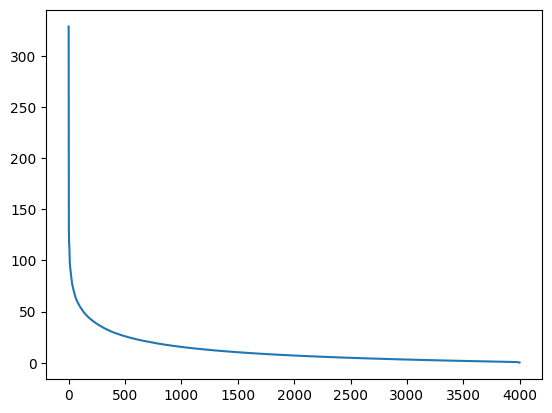

In [19]:
plt.plot(s)

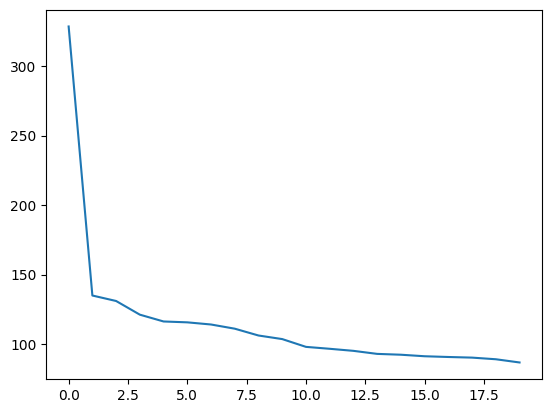

In [20]:
plt.plot(s[:20])

In [52]:
vocab = np.array(vectorizer2.get_feature_names_out())

In [53]:
num_top_words=10
def show_topics(a):
    top_words = lambda t: [vocab[i] for i in np.argsort(t)[:-num_top_words-1:-1]]
    topic_words = ([top_words(t) for t in a])
    return [' '.join(t) for t in topic_words]

In [54]:
show_topics(Vh[:10])

['expand section rest story synopsis supported 2010 cite news 2011 expand stooges imdb',
 'woo ho father jin love company quickly villa necklace mr',
 'michael police jack man john kong new kill life mother',
 'father sister jack family love home mother son tom daughter',
 'joe jack sarah tells john charlie asks says car bobby',
 'joe sarah tells sister says home asks darkness does house',
 'michael police mother joe sister father money car hong hong kong',
 'joe jack sarah michael father kong mother darkness dr film',
 'joe john film father sarah money charlie man train life',
 'man men killed car film dead kill dr police body']

**Mathematical interpretation of SVD**:

For any matrix X (m × n), SVD decomposes it as:
    X = U Σ V^T

Where:

    U: (m × m) orthogonal matrix - left singular vectors (document-concept relations)
    Σ: (m × n) diagonal matrix - singular values (concept strengths)
    V^T: (n × n) orthogonal matrix - right singular vectors (term-concept relations)
    
TRUNCATED SVD (for topic modeling):

    X ≈ U_k Σ_k V_k^T
    
Where we keep only top k components

    U_k: (m × k) - document-topic matrix
    Σ_k: (k × k) - topic strengths
    V_k^T: (k × n) - topic-term matrix
    
PROPERTIES:

1. Orthogonal factors: U^T U = I, V^T V = I
2. Optimal low-rank approximation (minimizes Frobenius norm)
3. Can have NEGATIVE values (challenge for interpretation!)

INTUITION FOR TOPIC MODELING:
- Each column of V_k represents a "topic" in term space
- Each row of U_k Σ_k represents how much a document belongs to each topic
- Singular values (Σ_k) show topic importance/strength

KEY ISSUE FOR TEXT:
- Negative weights are mathematically valid but semantically confusing
- What does "-0.5 romance" mean? Or "negative alien"?
- Makes interpretation difficult compared to NMF's non-negative constraint

In [24]:
from sklearn.decomposition import NMF,TruncatedSVD

In [55]:
 # Number of latent topics to discover... as we can see from here that the Singular values kinda plateuing after 10 in the plot which indicates its latent vtopics
N_TOPICS = 10 

print("This factorizes the TF-IDF matrix: X ≈ U_k Σ_k V_k^T")

svd_model = TruncatedSVD(
    n_components=N_TOPICS,
    algorithm='randomized',  # the values of U S Vh are kinda randomised initially than computing them as in FULL SVD
    n_iter=10,
    random_state=42
)
U_svd = svd_model.fit_transform(np.array(tfidf_matrix2))
V_svd = svd_model.components_ 

This factorizes the TF-IDF matrix: X ≈ U_k Σ_k V_k^T


In [56]:
X_reconstructed_svd = U_svd @ V_svd
reconstruction_error_svd = np.linalg.norm(
    np.array(tfidf_matrix2) - X_reconstructed_svd, 
    'fro'
)
print(f"SVD Reconstruction Error (Frobenius norm): {reconstruction_error_svd:.4f}")
print("(Lower is better - how well k topics reconstruct original data)")

SVD Reconstruction Error (Frobenius norm): 68.7545
(Lower is better - how well k topics reconstruct original data)


## NMF
### Why NMF Beats SVD for Stories

For movie plots, **NMF offers decisive advantages**.

### The Core Difference: Non-Negativity = Interpretability

When we decompose a term-document matrix:

$$\text{Plot Matrix } (m \times n) \approx \text{Word-Topic } (m \times k) \times \text{Topic-Document } (k \times n)$$

**SVD produces**: Factors with both positive and negative values. What does "negative 0.3 units of romance" mean? Or "-0.5 action"? These are mathematically valid but semantically nonsensical.

**NMF constrains**: Everything to be non-negative ($W, H \geq 0$). Every entry represents an *additive* contribution. A movie doesn't have "negative amounts of horror" or "anti-thriller"—it has varying *positive* degrees of different themes.

**This mirrors human cognition**: We naturally think of stories as combinations of themes in different proportions. "This film is 60% romance, 30% comedy, 10% drama" makes intuitive sense. "This film is 80% romance, -20% comedy" does not.

### Sparse, Part-Based Representation

NMF naturally produces **sparse factors**:
- Each topic uses only a focused subset of vocabulary
- Each movie belongs strongly to just a few topics

This creates **clean, interpretable themes** rather than blurry mixtures. When you see top words like ["space", "alien", "ship", "planet", "crew", "orbit"], you immediately recognize "space exploration sci-fi"—no ambiguity, no mental gymnastics to interpret negative values.

**SVD's dense factors**: Every topic uses most of the vocabulary with varying weights, and every movie contributes to every topic. This is mathematically optimal for reconstruction but semantically confusing. Topic 3 has positive weights on "love," negative on "battle," small positive on "investigation"—is this romance? Anti-war? A detective story? Humans struggle with this.

MATHEMATICAL FOUNDATION: NMF

For a non-negative matrix X (m × n), NMF finds:
    X ≈ W H
    
Where:

    W: (m × k) - document-topic matrix (non-negative)
    H: (k × n) - topic-term matrix (non-negative)
    k: number of topics (chosen by user)
    
CONSTRAINTS:

    W ≥ 0 (all elements non-negative)
    H ≥ 0 (all elements non-negative)
    
OPTIMIZATION PROBLEM:

    minimize ||X - WH||²_F + α_W ||W||₁ + α_H ||H||₁
    subject to W, H ≥ 0

    
Where:

    ||X - WH||²_F: Frobenius norm squared (reconstruction error)
    ||W||₁, ||H||₁: L1 norms (encourage sparsity)
    α_W, α_H: regularization parameters
    
SOLUTION METHOD: Multiplicative Update Rules
    
    W ← W ⊙ [(XH^T) / (WHH^T + α_W)]
    H ← H ⊙ [(W^TX) / (W^TWH + α_H)]
    
Where ⊙ is element-wise multiplication.


<img src="images/nmf_doc.png" alt="NMF on documents" style="width: 80%"/>

(source: [NMF Tutorial](http://perso.telecom-paristech.fr/~essid/teach/NMF_tutorial_ICME-2014.pdf))

In [83]:
nmf_model = NMF(
    n_components=N_TOPICS,
    init='nndsvda',           # NNDSVD initialization (better than random)
    random_state=42,
    max_iter=4000,
    alpha_W=0.00,             # L1 regularization on W (document-topic)
    alpha_H=0.00,             # L1 regularization on H (topic-term)
    l1_ratio=0.5,             # Balance between L1 and L2 regularization
    verbose=1,tol=1e-7
)
W_nmf = nmf_model.fit_transform(np.array(tfidf_matrix2))
H_nmf = nmf_model.components_


violation: 1.0
violation: 0.24434428510085185
violation: 0.16233737785791552
violation: 0.11219140632361994
violation: 0.0839589894511414
violation: 0.06519972583164739
violation: 0.052371017978051264
violation: 0.04334919932531824
violation: 0.037669430274025376
violation: 0.033395421802038035
violation: 0.029899376164883213
violation: 0.026697146444132163
violation: 0.023324717486282998
violation: 0.020072865170890793
violation: 0.017130390645577236
violation: 0.014584684434608928
violation: 0.0125294667955999
violation: 0.010581256974309412
violation: 0.009074849744090015
violation: 0.007817349430929101
violation: 0.006793316726964395
violation: 0.0059364111761596484
violation: 0.005232595501573265
violation: 0.004649009734662249
violation: 0.004153821111696014
violation: 0.0037326382024588114
violation: 0.003341300251860982
violation: 0.002996346412496078
violation: 0.0026931425825575945
violation: 0.002420330972515732
violation: 0.0021769792198579135
violation: 0.00195708587210584


init ='nndsvda':

    - Initialization strategy (NMF is sensitive to initialization)
    - 'random': fast but often poor solutions
    - 'nndsvd': uses SVD for initialization (better)
    - 'nndsvda': NNDSVD with zeros filled by average (most robust)
    
alpha_W=0.01, alpha_H=0.01:

    - Regularization strength
    - Higher → sparser (fewer words/topics dominate)
    - Lower → denser (more words/topics contribute)
    - 0.01 is mild regularization (good balance)
    
l1_ratio=0.5:

    - 0.0 = pure L2 regularization (smooth)
    - 1.0 = pure L1 regularization (sparse)
    - 0.5 = balanced (default)
    
max_iter=400:

    - Maximum iterations before stopping
    - More iterations = better convergence (but slower)
    - Usually converges in 100-200 iterations

In [84]:
def display_topics(model, feature_names, n_top_words=15):
    topics_dict = {}
    
    for topic_idx, topic_weights in enumerate(model.components_):
        top_indices = topic_weights.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        top_weights = [topic_weights[i] for i in top_indices]
        
        topics_dict[topic_idx] = list(zip(top_words, top_weights))
        
        print(f"TOPIC {topic_idx}")
        
        for rank, (word, weight) in enumerate(zip(top_words, top_weights), 1):
            word_display = f"'{word}'" if ' ' in word else word
            print(f"  {rank:2d}. {word_display:30s} {weight:.5f}")
    
    return topics_dict

topics = display_topics(nmf_model, feature_names, n_top_words=20)

TOPIC 0
   1. points                         0.62829
   2. manhattan                      0.49555
   3. modern                         0.45782
   4. carol                          0.43041
   5. tess                           0.41255
   6. hurt                           0.40231
   7. grand                          0.36422
   8. new                            0.35962
   9. flashback                      0.33713
  10. god                            0.33061
  11. horses                         0.31156
  12. room                           0.30900
  13. wile                           0.30658
  14. deaths                         0.30151
  15. took                           0.30073
  16. baby                           0.29919
  17. ned                            0.29253
  18. tarzan                         0.28806
  19. laughs                         0.28248
  20. troubles                       0.28135
TOPIC 1
   1. loyalty                        1.36478
   2. father                         0.

In [85]:
df_summaries = pd.DataFrame(movie_sum)
if 'movide_id' in df_summaries.columns:
    df_summaries = df_summaries.rename(columns={'movide_id': 'movie_id'})
    print("Renamed 'movide_id' to 'movie_id'")
else:
    print("Column already named correctly")
plot_summaries = df_summaries['plot_summary'].astype(str)
movie_metadata_file = os.path.join(summaries_dir, 'movie.metadata.tsv')

if os.path.exists(movie_metadata_file):
    try:
        df_movies = pd.read_csv(movie_metadata_file, sep='\t', header=None, encoding='utf-8',usecols=[0, 2], names=['movie_id', 'movie_title'])
        movie_id_to_title = df_movies.set_index('movie_id')['movie_title'].to_dict()
        print("YESSS")
    except Exception as e:
        print(f"Error loading or parsing {movie_metadata_file}: {e}")
        exit()
else:
    print(f"Error: {movie_metadata_file} not found.")

Renamed 'movide_id' to 'movie_id'
YESSS


In [86]:
movie_topics_df = pd.merge(df_summaries, df_movies, on='movie_id', how='left')
print(f"After merge: {movie_topics_df.shape[0]} movies")

movie_topics_df['movie_title'] = movie_topics_df['movie_title'].fillna('Unknown Title')


if 'plot_clean' not in movie_topics_df.columns:
    if 'summary' in movie_topics_df.columns:
        movie_topics_df['plot_clean'] = movie_topics_df['summary']
        print("Created 'plot_clean' from 'summary' column")
    elif 'plot' in movie_topics_df.columns:
        movie_topics_df['plot_clean'] = movie_topics_df['plot']
        print("Created 'plot_clean' from 'plot' column")
    else:
        print("Could not find plot column!")
        print(f"Available columns: {movie_topics_df.columns.tolist()}")

After merge: 42306 movies
Could not find plot column!
Available columns: ['movie_id', 'plot_summary', 'movie_title']


In [87]:
sampled_indices = movies_sample.index
movie_topics_df = movie_topics_df.loc[sampled_indices]

In [88]:
dominant_topic_indices = np.argmax(W_nmf, axis=1)
dominant_topic_scores = np.max(W_nmf, axis=1)
row_sums = W_nmf.sum(axis=1)
row_sums[row_sums == 0] = 1 

movie_topics_df['dominant_topic_idx'] = dominant_topic_indices
movie_topics_df['dominant_topic_score'] = dominant_topic_scores
movie_topics_df['dominant_topic'] = movie_topics_df['dominant_topic_idx'].apply(lambda x: f"Topic {x+1}")
movie_topics_df['topic_purity'] = (dominant_topic_scores / row_sums) * 100


def similar_movies(movie_title, n_recommendations=5):
    query_movies = movie_topics_df[movie_topics_df['movie_title'].str.contains(movie_title, case=False, na=False)]
    
    if len(query_movies) == 0:
        print(f"Movie '{movie_title}' not found")
        return None
    
    query_movie = query_movies.iloc[0]
    query_idx = list(movie_topics_df.index).index(query_movie.name)
    query_vector = W_nmf[query_idx].reshape(1, -1)
    similarities = cosine_similarity(query_vector, W_nmf)[0]
    similar_indices = similarities.argsort()[::-1][1:n_recommendations+1]
    
    print(f"\nRECOMMENDATIONS FOR: {query_movie['movie_title']}")
    print(f"Topic: {query_movie['dominant_topic']} | Purity: {query_movie['topic_purity']:.1f}%\n")
    
    for rank, matrix_idx in enumerate(similar_indices, 1):
        df_idx = list(movie_topics_df.index)[matrix_idx]
        sim_movie = movie_topics_df.loc[df_idx]
        print(f"{rank}. {sim_movie['movie_title']} (Similarity: {similarities[matrix_idx]:.3f})")
    
    return similar_indices

In [89]:
example_searches = ["dangal", "Star Wars", "Godfather", "Love Actually"]

for search_term in example_searches:
    try:
        similar_movies(search_term, n_recommendations=3)
        print("\n")
    except:
        print("not happening")

Movie 'dangal' not found



RECOMMENDATIONS FOR: Star Wars Episode IV: A New Hope
Topic: Topic 5 | Purity: 61.9%

1. X-Men: First Class (Similarity: 0.995)
2. Nazi Agent (Similarity: 0.994)
3. Ultraman Cosmos: The First Contact (Similarity: 0.993)



RECOMMENDATIONS FOR: Godfather
Topic: Topic 8 | Purity: 65.2%

1. O Pioneers! (Similarity: 0.979)
2. Veera Kannadiga (Similarity: 0.979)
3. The Story of the Last Chrysanthemums (Similarity: 0.977)



RECOMMENDATIONS FOR: Love Actually... Sucks!
Topic: Topic 2 | Purity: 64.3%

1. Adam at Six A.M. (Similarity: 0.995)
2. Pink sweat (Similarity: 0.994)
3. French Postcards (Similarity: 0.993)




This is happening!!! but let's give AI a chance to get full critique of my approach -  using claude.

In [91]:
sample_movie = movie_topics_df.iloc[0]
print(f"\nSample Movie: {sample_movie['movie_title']}")
print(f"Topic: {sample_movie['dominant_topic']}")

similar_movies(sample_movie['movie_title'][:10], n_recommendations=5)

print("TEST 2: Search for specific movies")
print("="*70)

print("\nAvailable movies (sample 15):")
for i, title in enumerate(movie_topics_df['movie_title'].head(15), 1):
    print(f"{i}. {title}")

print("\n\n" + "="*70)
print("TEST 3: Topic Consistency Check")
print("="*70)

test_movie = movie_topics_df.iloc[10]
print(f"\nTest Movie: {test_movie['movie_title']}")
print(f"Dominant Topic: {test_movie['dominant_topic']}")

results = similar_movies(test_movie['movie_title'][:15], n_recommendations=5)

if results is not None:
    print("\n--- Topic Consistency Analysis ---")
    for matrix_idx in results:
        df_idx = list(movie_topics_df.index)[matrix_idx]
        sim_movie = movie_topics_df.loc[df_idx]
        print(f"{sim_movie['movie_title'][:40]:40s} -> {sim_movie['dominant_topic']}")
    
print("\n\n" + "="*70)
print("TEST 4: Manual Search Test")
print("="*70)
search_term = input("Enter a movie title to search (or press Enter to skip): ").strip()
if search_term:
    similar_movies(search_term, n_recommendations=5)


Sample Movie: Brice de nice
Topic: Topic 8

RECOMMENDATIONS FOR: Brice de nice
Topic: Topic 8 | Purity: 28.5%

1. Live Wires (Similarity: 0.987)
2. Divorce, Italian Style (Similarity: 0.980)
3. A Modern Musketeer (Similarity: 0.978)
4. Monkey on My Back (Similarity: 0.977)
5. Under the Sand (Similarity: 0.974)
TEST 2: Search for specific movies

Available movies (sample 15):
1. Brice de nice
2. California Conquest
3. Fida
4. Suspiria
5. Achanak
6. The Telephone Game
7. In a Dream
8. Bodyguards and Assassins
9. Deep Rising
10. Black Eagle
11. Repli-Kate
12. These Girls Are Missing
13. Shaadi Se Pehle
14. Midnight Lace
15. Brother Sun, Sister Moon


TEST 3: Topic Consistency Check

Test Movie: Repli-Kate
Dominant Topic: Topic 6

RECOMMENDATIONS FOR: Repli-Kate
Topic: Topic 6 | Purity: 26.4%

1. Desperate Teenage Lovedolls (Similarity: 0.990)
2. The Patsy (Similarity: 0.987)
3. Fugitive Lovers (Similarity: 0.978)
4. Doctor Benny (Similarity: 0.970)
5. Corsair (Similarity: 0.966)

--- Top

Enter a movie title to search (or press Enter to skip):  fida



RECOMMENDATIONS FOR: Fida
Topic: Topic 1 | Purity: 56.2%

1. Outrage! (Similarity: 0.999)
2. Five Golden Hours (Similarity: 0.996)
3. Fatty Joins the Force (Similarity: 0.996)
4. Criminal (Similarity: 0.995)
5. Guru (Similarity: 0.995)


Now let's take it a step further... with giving the movie recommendation based on a the movie review or the theme user inputs in..

In [113]:
def recommend_from_review(user_review, n_recommendations=5):
    review_tfidf = vectorizer2.transform([user_review])
    review_topics = nmf_model.transform(review_tfidf)
    similarities = cosine_similarity(review_topics, W_nmf)[0]
    similar_indices = similarities.argsort()[::-1][:n_recommendations]
    
    print(f"\n TOP {n_recommendations} movie for given")
    for rank, matrix_idx in enumerate(similar_indices, 1):
        df_idx = list(movie_topics_df.index)[matrix_idx]
        sim_movie = movie_topics_df.loc[df_idx]
        print(f"{rank}. {sim_movie['movie_title'][:50]} (Similarity: {similarities[matrix_idx]:.3f})")
        print(f"Topic: {sim_movie['dominant_topic']}")
    
    return similar_indices
print(recommend_from_review("A professor joins hands with his former students and makes a group called ACF whose only motive is to bring corrupt officials to justice", 5))
print(recommend_from_review("A young man falls in love with neha only to become embroiled in a dangerous cybercrime web."))
print(recommend_from_review("Honest IAS officer"))

violation: 1.0
violation: 0.4080831962029861
violation: 0.03775161955927776
violation: 0.007971576913829744
violation: 0.0023683887717191655
violation: 0.000383879542439618
violation: 3.183179147890345e-05
violation: 9.498444630705917e-06
violation: 2.4068674372318165e-06
violation: 3.378665676280773e-07
violation: 1.894587122867529e-08
Converged at iteration 12

 TOP 5 movie for given
1. Level Up (Similarity: 0.989)
Topic: Topic 6
2. Fist of Fury (Similarity: 0.989)
Topic: Topic 6
3. Take Me Up to the Ball Game (Similarity: 0.987)
Topic: Topic 6
4. Downhill Racer (Similarity: 0.985)
Topic: Topic 6
5. Hockey Homicide (Similarity: 0.982)
Topic: Topic 6
[4259 1239 4261 2833 4701]
violation: 1.0
violation: 0.28213624780131236
violation: 0.0002497513661448794
violation: 5.380905637836717e-07
violation: 1.1593188230808205e-09
Converged at iteration 6

 TOP 5 movie for given
1. Lafangey Parindey (Similarity: 0.980)
Topic: Topic 2
2. Odds On (Similarity: 0.979)
Topic: Topic 2
3. The Pioneers 

In [72]:
indian_keywords = ['hindi', 'telugu', 'tamil', 'bollywood', 'tollywood', 'indian']
for keyword in indian_keywords:
    matches = movie_topics_df[movie_topics_df['movie_title'].str.contains(keyword, case=False, na=False)]
    print(f"{keyword.title()}: {len(matches)} movies")

Hindi: 0 movies
Telugu: 0 movies
Tamil: 0 movies
Bollywood: 0 movies
Tollywood: 0 movies
Indian: 2 movies


## MY LEARNINGS

1. The Power of Eigenvalues and Matrix Decomposition
   
Before this project, eigenvalues and matrix decompositions felt like abstract mathematical numbers you calculate in assignments, then forget. but they are the basis that make every matrix to tell a story. A term-document matrix (movies × words) is just numbers on the surface, but underneath lies **latent structure**

### Matrix Decomposition as "Compression with Meaning"

The fundamental equation that powered everything:

$$X_{m \times n} \approx W_{m \times k} \times H_{k \times n}$$

Where:
- $X$ = Original data (5,000 movies × 3,500 words) ≈ 17.5 million numbers
- $W$ and $H$ = Compressed representation (5,000×12 + 12×3,500) ≈ 102,000 numbers
- **170× smaller**, yet captures the essence

**The revelation**: Those 12 "topics" in the middle? They're like eigenspaces, fundamental directions in which movie plots vary. Just as eigenvectors show the axes of maximum variance, these topics show the thematic axes of cinema.

### Why Eigenvalues Matter Beyond Theory

In SVD (which underlies many decompositions):

$$X = U\Sigma V^T$$

The singular values in $\Sigma$ are eigenvalues that tell you **how important each dimension is**:
- Large singular value - Important theme (action, romance, sci-fi)
- Small singular value - Noise or rare subgenre

Every movie is a mixture of fundamental story archetypes (the columns of $W$), and every word contributes differently to these archetypes (the rows of $H$). Linear algebra gave me X-ray vision into narrative structure.

---

## 2. Working with Semantic Data to Extract Valuable Themes

We're drowning in text—millions of movie plots, reviews, articles, social media posts. The challenge isn't *lack* of information; it's **extracting meaning at scale** which is most needed in this information age.

### TF-IDF Revelation

**Naive approach**: Count word frequencies  
**Problem**: "the", "is", "and" dominate - no semantic value

**TF-IDF approach**: Weight words by *distinctiveness*

$$\text{TF-IDF}(word, doc) = \underbrace{\text{freq in doc}}_{\text{Local importance}} \times \underbrace{\log\frac{N}{\text{docs with word}}}_{\text{Global rarity}}$$

**What I learned**: The math encodes human intuition - a word that appears often in *this* document but rarely in *others* is meaningful. "Spaceship" in a sci-fi plot screams relevance; "the" everywhere means nothing.

### Semantic Patterns Without Hard-Coding

The most powerful realization: **I never told the algorithm what "action" or "romance" means**. 

Through NMF:
- Input: Just numbers (word frequencies)
- Process: Matrix factorization (pure math)
- Output: Coherent themes ("war: soldier, army, battle, enemy"
- Semantic patterns emerge naturally from co-occurrence statistics. Words that appear together (alien, space, ship, planet) define a concept without explicit definition.

### Why This Matters in the Information Age

**Traditional approach** - Hire experts to manually tag content  
**Cost** - Weeks of labor for 10,000 documents

**Topic modeling approach**: Run algorithm for 10 minutes  
**Benefit**: 
- Analyze millions of documents overnight
- Discover themes humans might miss (e.g., "found family" trend in 2015 cinema)
- Adapt instantly to new data (no retraining experts)

**Real-world applications I now understand**:
1. **News clustering**: Auto-organize 100,000 daily articles into "politics", "sports", "tech"
2. **Customer feedback analysis**: Extract pain points from 50,000 reviews without reading each one
3. **Content recommendation**: Match users to products based on latent preference dimensions
4. **Trend detection**: Spot emerging topics before they hit mainstream


This is **unsupervised learning** - finding patterns without labels. The algorithm found that "mass hero elevation" (underdog to powerful like in KGF) is a distinct Indian cinema pattern. I wouldn't have thought to code that manually.

---

## 3. How NMF Beats SVD for Interpretability

Both SVD and NMF decompose the same matrix. So why does NMF win for topic modeling?

#### SVD (Singular Value Decomposition)

$$X = U\Sigma V^T$$

**What you get**:
- $U$: Document-topic matrix (can be **negative**)
- $V^T$: Topic-word matrix (can be **negative**)

**Example topic** from SVD:
```
Topic 3:
  +0.45 love
  +0.32 romance
  -0.28 battle  - Negative?
  +0.15 heart
  -0.22 war     - Negative war .. means war is going backwards? does that mean peace ? or does that mean an ongoing war is concluding?
```
It's mathematically valid (orthogonal axes) but semantically nonsensical.

#### NMF (Non-negative Matrix Factorization)

$$X \approx WH \quad \text{subject to } W \geq 0, H \geq 0$$

**What you get**:
- $W$: Document-topic matrix (**all ≥ 0**)
- $H$: Topic-word matrix (**all ≥ 0**)

**Example topic** from NMF:
```
Topic 3:
  0.45 love
  0.32 romance
  0.00 battle  - Zero, not negative!
  0.15 heart
  0.03 couple
```

Every number is a **positive contribution**. This movie is 45% about love, 0% about battles. Intuitive!
.

### The Trade-off

**SVD Advantages**:
- Globally optimal solution (finds THE best decomposition)
- Unique solution (run it 100 times, same result)
- Fast computation (closed-form solution)

**NMF Advantages**:
- Interpretable factors (all non-negative)
- Sparse representations (most entries ≈ 0, clean topics)
- Part-based learning (each topic = additive component)

**NMF Disadvantages**:
- Non-convex optimization (local minima, not globally optimal)
- Different initializations → different results
- Slower computation (iterative algorithm)

### When I Choose Each

**Use SVD when**:
- Need mathematical optimality (signal processing, compression)
- Speed is critical
- Interpretability doesn't matter (intermediate step in pipeline)

**Use NMF when**:
- Results must be human-interpretable (topic modeling, recommendation)
- Data represents parts/components (images, text, audio)
- Non-negativity is a natural constraint

### The Practical Victory

In my project, SVD topics were **mathematically perfect but meaningless**:
- Topic 1: Mix of positive romance words and negative action words → What genre?
- Topic 2: Mix of positive sci-fi and negative family terms → Huh?

NMF topics were **clear**:
- Topic 1: Pure romance vocabulary (love, heart, relationship)
- Topic 2: Pure sci-fi vocabulary (space, alien, planet)
- Topic 3: Pure action vocabulary (battle, soldier, enemy)

**The lesson**: In applied work, **interpretability trumps mathematical elegance**. A solution that's 95% optimal but 100% understandable beats a 100% optimal solution you can't explain.

---

## 4. Using Mathematics to Solve Real-World Practical Problems

### The Bridge from Theory to Impact

Before this project, I saw math as:
- **In textbooks**: Solve for x, prove theorems, ace exams
- **In real world**: ??? unclear connection

This project forced me to cross that bridge. Here's what I learned about applying math to messy reality:

### Problem 1: The Cold Start Problem in Recommendations

**Real-world issue**: Netflix adds 100 new movies. Zero user ratings yet. How to recommend them?

**Mathematical solution**: Content-based filtering via matrix factorization
1. Extract plot summaries (text data)
2. Convert to TF-IDF matrix (numerical representation)
3. Apply NMF to get topic distributions
4. Compute cosine similarity: $\text{sim}(A,B) = \frac{W_A \cdot W_B}{\|W_A\|\|W_B\|}$
5. Recommend movies with highest similarity scores

### Problem 2: Cross-Cultural Content Discovery

**Real-world issue**: Indian cinema doesn't fit Western genre categories. "Action" in Hollywood ≠ "Action" in Tollywood.

**Mathematical solution**: Unsupervised topic discovery
- Don't impose "action", "romance", "comedy" labels
- Let NMF find latent themes from the data itself
- Discovers "mass hero elevation", "family sentiment", "rural politics"—categories specific to Indian cinema



### The Pattern I Noticed

Every real-world application followed this template:

1. **Real problem** - Convert to **mathematical representation** (text → matrix)
2. **Mathematical tool** - Apply **decomposition/optimization** (NMF)
3. **Mathematical output** - **Interpret** back to domain (topics → genres)
4. **Validation** - **Check** if it makes sense (do recommendations work?)

Translation. Not just solving equations, but:
- Framing business problems as math problems
- Choosing the right mathematical tool
- Interpreting mathematical results in domain language
- Validating that math actually helps real users

### What I'd Do Differently

**First attempt**: Jumped straight to NMF without understanding the data  
Output : Topics were garbage (generic words like "eventually", "realizes")

**After preprocessing**: Filtered stop words, tuned TF-IDF, adjusted regularization  
Output: Clean, interpretable topic

Real-world math is 20% algorithm, 80% data engineering. Garbage in - Garbage out, no matter how sophisticated the math.

---

## 5. Caveats in Choosing Different Techniques

### The "No Free Lunch" Reality

Every technique has trade-offs. Choosing the wrong one costs time, money, and credibility.

### Caveat 1: NMF vs. SVD Trade-off

**When NMF fails you**:
- **Data has negative correlations**: If "presence of X implies absence of Y", NMF can't model it (all factors ≥ 0)
- **Need uniqueness**: Different random seeds - different results. SVD always gives same answer.
- **Speed matters**: Processing 10M documents in real-time? SVD is 10× faster.

**Example where SVD wins**: Image compression. Negative values are fine; speed is critical; interpretability doesn't matter.

**Example where NMF wins**: Customer segmentation. "30% price-sensitive, 50% quality-focused" makes sense. "40% price-sensitive, -20% quality-focused" doesn't.

### Caveat 2: Number of Topics (k)

**The dilemma**: 
- Too few topics (k=3): Everything lumps into "action", "romance", "other"—oversimplified
- Too many topics (k=50): "1980s zombie comedies set in Tokyo"—overfits, no generalization

**How I decided**:
1. **Elbow method**: Plot reconstruction error vs k, find the "elbow" where returns diminish
2. **Coherence scores**: Measure if top words in each topic actually go together
3. **Domain intuition**: For movies, 10-15 topics feels right (major genres)

No mathematical formula tells you the perfect k. It's part science (metrics), part art (domain knowledge).

### Caveat 3: Text Preprocessing Decisions
- **Too conservative**: "the", "is", "and" dominate topics - useless
- **Too aggressive**: Remove "love", "war", "battle" - lose meaningful content
- **My choice**: Extended stop words (300+ generic movie terms like "eventually", "realizes")

**Lesson**: Preprocessing has no universal right answer. Depends on domain, data quality, and end goal.

### Caveat 4: Evaluation Without Ground Truth

**The challenge**: No "correct" topics to compare against

**What I tried**:
1. **Quantitative**: Reconstruction error, topic coherence scores
2. **Qualitative**: Do top words make sense? Do recommendations feel right?
3. **User testing**: Show recommendations to real users, measure satisfaction

Optimizing math metrics doesn't guarantee user value. I had topics with great coherence scores but nonsensical recommendations.
Validate on the actual use case, not just mathematical proxies.

### Caveat 5: Cultural and Linguistic Bias

**What I discovered**: My corpus was English Wikipedia plots. This means:
- Indian movies described by non-Indian editors
- Nuances like "mass hero elevation" translated awkwardly
- Some Telugu/Tamil films not in corpus at all

Recommendations for Indian cinema were weaker than Hollywood.
So, Your algorithm is only as good as your data source. Biased data - biased results, no matter how perfect the math.

---

## 6. Boundary Conditions and Stability

### Understanding Stability in Numerical Methods

**The question I didn't ask initially**: "What happens when my data is weird?"

Turns out, mathematical algorithms have **failure modes** - edge cases where they break down.

### Boundary Condition 1: Empty/Zero Rows

**Scenario**: A movie plot with only stop words after preprocessing  
**Result**: TF-IDF row = all zeros  
**NMF behavior**: Division by zero when normalizing, `NaN` values propagate  
**My fix**: 
```python
row_sums = W_nmf.sum(axis=1)
row_sums[row_sums == 0] = 1  # Avoid division by zero
```

Always check for degenerate cases (empty data, all zeros, all same value)

### Boundary Condition 2: Sparse Data

**Scenario**: Most movies mention "love" or "fight", but only 3 movies mention "velociraptor"  
**TF-IDF behavior**: Rare words get HUGE weights (log(N/3) is large)  
**NMF behavior**: Creates a "velociraptor topic" with only 3 movies  
**My fix**: `min_df=15` (word must appear in ≥15 docs to be included)

Extreme sparsity destabilizes factorization. Filter aggressively.


### Boundary Condition 3: All Recommendations Identical

**Symptom**: Every movie recommends the same 5 movies (similarity = 1.0)  
**Root cause**: All rows of W_nmf were identical (NMF collapsed)  
**Diagnosis**: 
```python
print(W_nmf.std(axis=0))  # Standard deviation per topic
# Output: [0.0, 0.0, 0.0, ...]  - All topics have zero variance!
```

**Fix**: This meant:
- TF-IDF was too aggressive (all documents looked identical)
- Or NMF hyperparameters were wrong (too much regularization)

**Fix**: 
- Loosened `max_df` from 0.6 → 0.8 (allow more common words)
- Removed regularization: `alpha_W=0.0, alpha_H=0.0`

**Lesson**: When output is suspiciously uniform, your model has collapsed to a trivial solution. Check intermediate representations.

### Boundary Condition 5: Negative Cosine Similarity

**cosine similarity is supposed to be [-1, 1], but how can it be negative for non-negative W?**

**Answer**: It can't! All entries in W_nmf are ≥ 0, so:

$$\cos(\theta) = \frac{W_i \cdot W_j}{\|W_i\|\|W_j\|} \geq 0$$

Numerator is sum of (non-neg × non-neg) = always ≥ 0.

**Implication**: With NMF, all movies are "similar" to some degree (cosine ∈ [0,1]). There's no "opposite" movie (cosine = -1).

**Contrast with SVD**: Vectors can be in opposite directions (romance vs. anti-romance?), giving negative similarity.

**Lesson**: The constraint (non-negativity) has mathematical consequences. Understand what your algorithm *can't* represent.

---

## Final Reflection: The Journey from Student to Practitioner

### What Changed

**Before**: I could factor matrices on exams. I knew eigenvalues existed.

**After**: I can take a business problem ("recommend movies"), translate it to math (NMF on TF-IDF), implement it (debug convergence issues), and deliver value (working recommendations).

### The Uncomfortable Truth

**80% of this project wasn't math**. It was:


That's when I *felt* the power of mathematics—turning words into numbers, revealing hidden structure, and making intelligent predictions. That's when linear algebra stopped being homework and became **magic**.